In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/resnet_features.csv')
df.shape

(3898, 2049)

In [ ]:
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_2039,feature_2040,feature_2041,feature_2042,feature_2043,feature_2044,feature_2045,feature_2046,feature_2047,label
0,0.039164,0.617642,0.107853,0.376942,0.089375,0.042309,0.135151,0.246696,0.143043,0.216616,...,0.265314,0.518185,0.623599,0.150417,0.017330,0.218101,0.447609,0.877618,0.249591,AD
1,0.253862,0.289451,0.183565,0.503103,0.000000,0.039847,0.640761,0.352711,0.710503,0.498195,...,0.012770,0.620834,0.281454,0.323947,0.003298,0.073039,0.590564,1.009496,1.523529,AD
2,0.167927,0.537961,0.123549,0.713740,0.080809,0.513323,0.790639,0.229424,0.334899,0.273876,...,0.010286,0.851536,0.294417,0.066262,0.002479,0.108432,0.983083,0.705193,1.205853,AD
3,0.155322,0.372970,0.098443,0.384186,0.000000,0.006767,0.399594,0.515298,0.849680,0.412460,...,0.022496,0.642848,0.213399,0.262902,0.013065,0.014067,0.698723,0.844151,1.481523,AD
4,0.120427,0.113370,0.089176,0.423628,0.000719,0.041530,0.666011,0.591804,0.625362,0.500816,...,0.018377,0.751583,0.114963,0.364352,0.025591,0.002929,0.731588,1.326745,1.401907,AD


# Task
Split the `df` DataFrame into features (X) and labels (y), then further split the data into training, validation, and test sets with a 70:15:15 ratio respectively, ensuring stratification by the 'label' column.

## Prepare data for splitting

### Subtask:
Separate the features (X) from the labels (y) in the dataframe.


**Reasoning**:
To separate the features (X) from the labels (y), I will drop the 'label' column from the DataFrame to create X, and assign the 'label' column to y.



In [ ]:
X = df.drop('label', axis=1)
y = df['label']

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

Shape of X: (3898, 2048)
Shape of y: (3898,)


## Split data into training and temporary sets

### Subtask:
Divide the data into a training set and a temporary set (which will later be split into validation and test sets), ensuring stratification by the 'label' column. This initial split will allocate 70% to training and 30% to the temporary set.


**Reasoning**:
The subtask requires splitting the data into training and temporary sets, ensuring stratification. Importing `train_test_split` is the first step to achieve this.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print('Shape of X_train:', X_train.shape)
print('Shape of X_temp:', X_temp.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_temp:', y_temp.shape)

Shape of X_train: (2728, 2048)
Shape of X_temp: (1170, 2048)
Shape of y_train: (2728,)
Shape of y_temp: (1170,)


In [ ]:
print('Label distribution in y_train:')
print(y_train.value_counts())
print('\nLabel distribution in y_temp:')
print(y_temp.value_counts())

Label distribution in y_train:
label
AD     1081
MCI     866
CN      781
Name: count, dtype: int64

Label distribution in y_temp:
label
AD     463
MCI    372
CN     335
Name: count, dtype: int64


In [ ]:
# Split temporary set into validation and test (15% / 15%) with stratification
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print('X_val:', X_val.shape, 'X_test:', X_test.shape)
print('y_val:', y_val.shape, 'y_test:', y_test.shape)

X_val: (585, 2048) X_test: (585, 2048)
y_val: (585,) y_test: (585,)


In [ ]:
print('Label distribution in y_train:')
print(y_train.value_counts())
print('\nLabel distribution in y_val:')
print(y_val.value_counts())
print('\nLabel distribution in y_test:')
print(y_test.value_counts())

Label distribution in y_train:
label
AD     1081
MCI     866
CN      781
Name: count, dtype: int64

Label distribution in y_val:
label
AD     231
MCI    186
CN     168
Name: count, dtype: int64

Label distribution in y_test:
label
AD     232
MCI    186
CN     167
Name: count, dtype: int64


In [ ]:
# Encode labels (AD, CN, MCI) to integers for modeling
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)
class_names = list(le.classes_)
print('Classes:', class_names)

Classes: ['AD', 'CN', 'MCI']


## CoCa setup for AD/CN/MCI classification (images)

This skeleton trains a linear classifier on top of CoCa's image encoder embeddings.

Requirements:
- Images organized in directories: `.../dataset_root/AD`, `.../dataset_root/CN`, `.../dataset_root/MCI`.
- Adjust `data_root` below.

Note: This section uses raw images, not the precomputed `resnet_features.csv`.

In [ ]:
# Install dependencies
!pip install -q qpsolvers cvxopt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (3898, 2049)
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.039164   0.617642   0.107853   0.376942   0.089375   0.042309   
1   0.253862   0.289451   0.183565   0.503103   0.000000   0.039847   
2   0.167927   0.537961   0.123549   0.713740   0.080809   0.513323   
3   0.155322   0.372970   0.098443   0.384186   0.000000   0.006767   
4   0.120427   0.113370   0.089176   0.423628   0.000719   0.041530   

   feature_6  feature_7  feature_8  feature_9  ...  feature_2039  \
0   0.135151   0.246696   0.143043   0.216616  ...      0.265314   
1   0.640761   0.352711   0.710503   0.498195  ...      0.012770   
2   0.790639   0.229424   0.334899   0.273876  ...      0.010286   
3   0.399594   0.515298   0.849680   0.412460  ...      0.022496   
4   0.666011   0.591804   0.625362   0.500816  ...      0.018377   

   feat

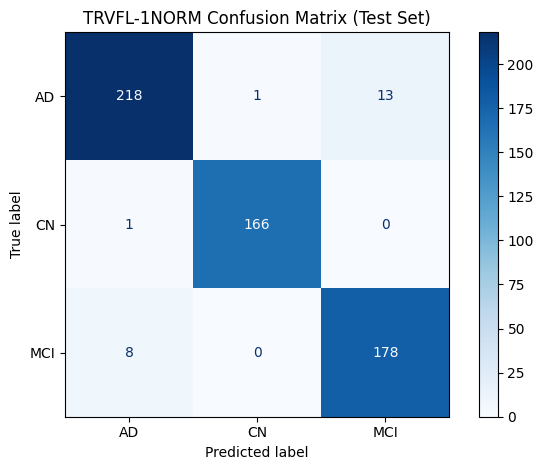


Test Set Classification Report:
              precision    recall  f1-score   support

          AD     0.9604    0.9397    0.9499       232
          CN     0.9940    0.9940    0.9940       167
         MCI     0.9319    0.9570    0.9443       186

    accuracy                         0.9607       585
   macro avg     0.9621    0.9636    0.9627       585
weighted avg     0.9609    0.9607    0.9607       585



In [ ]:
# ====================================================
# STEP 1: Mount Drive and Load Dataset
# ====================================================
from google.colab import drive

try:
    drive.mount('/content/drive')
except Exception:
    pass  # Ignore if not in Colab

# Replace the path below with your actual file path inside Drive
file_path = "/content/drive/MyDrive/resnet_features.csv"

# ====================================================
# STEP 2: Install Dependencies
# ====================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from qpsolvers import solve_qp
import time
from itertools import product

# ====================================================
# STEP 3: Load and Prepare Data
# ====================================================
df = pd.read_csv(file_path)
print("Dataset shape:", df.shape)
print(df.head())

# Assuming the last column is the label
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

# Encode labels
le = LabelEncoder()
y_int = le.fit_transform(y_raw)
class_names = list(le.classes_)
num_classes = len(class_names)

print(f"\nClasses: {class_names}")
print(f"Number of classes: {num_classes}")

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ====================================================
# STEP 4: Split Data (70:15:15)
# ====================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_int, test_size=0.3, random_state=42, stratify=y_int
)
print('Shape of X_train:', X_train.shape)
print('Shape of X_temp:', X_temp.shape)

# Further split temp into validation and test (15% / 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print('X_val:', X_val.shape, 'X_test:', X_test.shape)
print('y_val:', y_val.shape, 'y_test:', y_test.shape)

print('\nLabel distribution in y_train:')
print(pd.Series(y_train).value_counts())
print('\nLabel distribution in y_val:')
print(pd.Series(y_val).value_counts())
print('\nLabel distribution in y_test:')
print(pd.Series(y_test).value_counts())

# ====================================================
# STEP 5: TRVFL-1NORM Implementation (Multi-class with Probabilities)
# ====================================================

def trvfl_nclass(X_train, y_train, X_val, y_val, X_test, y_test, L, c1, random_state=42):
    """
    TRVFL-1NORM (General N-Class Classifier Version) with continuous margins & softmax probabilities.

    Parameters:
    -----------
    X_train, y_train : Training data and labels (encoded ints)
    X_val, y_val     : Validation data and labels
    X_test, y_test   : Test data and labels
    L                : int, number of hidden neurons
    c1               : float, regularization parameter for QP upper bound
    random_state     : int, random seed

    Returns:
    --------
    results : dict containing predictions, accuracies, confusion matrices, margins & probabilities.
    """
    np.random.seed(random_state)

    classes = np.unique(y_train)
    k = len(classes)
    n_samples, n_features = X_train.shape

    # Random weights & biases for hidden layer
    w_vec = np.random.randn(n_features, L)
    b_vec = np.random.randn(L)

    def hidden_features(X):
        H = 1.0 / (1.0 + np.exp(-(X @ w_vec + b_vec)))
        return np.hstack((H, X))  # direct links concatenated

    H_train = hidden_features(X_train)
    H_val = hidden_features(X_val)
    H_test = hidden_features(X_test)

    n_hidden = H_train.shape[1]

    betas = []

    for cls in classes:
        pos_idx = (y_train == cls)
        neg_idx = (y_train != cls)
        U = H_train[pos_idx]
        V = H_train[neg_idx]
        m1 = U.shape[0]
        m2 = V.shape[0]
        c3 = 1e-4
        c4 = 1e-4
        HTH = U.T @ U
        invHTH = np.linalg.inv(HTH + c3 * np.eye(n_hidden))
        GINVGT = V @ invHTH @ V.T
        GINVGT = (GINVGT + GINVGT.T) / 2
        GTG = V.T @ V
        invGTG = np.linalg.inv(GTG + c4 * np.eye(n_hidden))
        HINVHT = U @ invGTG @ U.T
        HINVHT = (HINVHT + HINVHT.T) / 2
        P1 = GINVGT
        q1 = -np.ones(m2)
        u1 = solve_qp(P1, q1, lb=np.zeros(m2), ub=c1 * np.ones(m2), solver='cvxopt')
        P2 = HINVHT
        q2 = -np.ones(m1)
        u2 = solve_qp(P2, q2, lb=np.zeros(m1), ub=c1 * np.ones(m1), solver='cvxopt')
        beta1 = -invHTH @ V.T @ u1
        beta2 =  invGTG @ U.T @ u2
        betas.append((beta1, beta2))

    def compute_margins(H, betas):
        # margin_j = |H beta2_j| - |H beta1_j| (higher => closer to positive region)
        margins = []
        for (beta1, beta2) in betas:
            s1 = np.abs(H @ beta1)
            s2 = np.abs(H @ beta2)
            margins.append(s2 - s1)
        return np.column_stack(margins)  # shape (n_samples, k)

    train_margins = compute_margins(H_train, betas)
    val_margins   = compute_margins(H_val, betas)
    test_margins  = compute_margins(H_test, betas)

    def softmax(m):
        m_shift = m - m.max(axis=1, keepdims=True)
        exps = np.exp(m_shift)
        return exps / exps.sum(axis=1, keepdims=True)

    train_probs = softmax(train_margins)
    val_probs   = softmax(val_margins)
    test_probs  = softmax(test_margins)

    pred_train = classes[np.argmax(train_margins, axis=1)]
    pred_val   = classes[np.argmax(val_margins, axis=1)]
    pred_test  = classes[np.argmax(test_margins, axis=1)]

    train_accuracy = 100 * np.mean(pred_train == y_train)
    val_accuracy   = 100 * np.mean(pred_val == y_val)
    test_accuracy  = 100 * np.mean(pred_test == y_test)

    train_confmat = confusion_matrix(y_train, pred_train, labels=classes)
    val_confmat   = confusion_matrix(y_val, pred_val, labels=classes)
    test_confmat  = confusion_matrix(y_test, pred_test, labels=classes)

    return {
        'pred_train': pred_train,
        'pred_val': pred_val,
        'pred_test': pred_test,
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'test_accuracy': test_accuracy,
        'train_confmat': train_confmat,
        'val_confmat': val_confmat,
        'test_confmat': test_confmat,
        'train_margins': train_margins,
        'val_margins': val_margins,
        'test_margins': test_margins,
        'train_probs': train_probs,
        'val_probs': val_probs,
        'test_probs': test_probs,
        'betas': betas,
        'w_vec': w_vec,
        'b_vec': b_vec,
        'classes': classes
    }

# ====================================================
# STEP 6: Train TRVFL with Default Parameters
# ====================================================
print("\n" + "="*60)
print("TRAINING TRVFL-1NORM WITH DEFAULT PARAMETERS (MULTI-CLASS)")
print("="*60)

default_L = 100
default_c1 = 1.0

print(f"\nDefault Parameters:")
print(f"  Hidden Neurons (L): {default_L}")
print(f"  Regularization (c1): {default_c1}")

start_time = time.time()
results = trvfl_nclass(X_train, y_train, X_val, y_val, X_test, y_test, L=default_L, c1=default_c1)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")
print(f"\nTraining Accuracy: {results['train_accuracy']:.2f}%")
print(f"Validation Accuracy: {results['val_accuracy']:.2f}%")
print(f"Test Accuracy: {results['test_accuracy']:.2f}%")

print("\nTest Set Confusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=results['test_confmat'], display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('TRVFL-1NORM Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

print("\nTest Set Classification Report:")
print(classification_report(y_test, results['pred_test'], target_names=class_names, digits=4))

In [ ]:
# ====================================================
# HYPERPARAMETER TUNING SETUP FOR TRVFL
# ====================================================
from itertools import product

# Define hyperparameter grid
param_grid = {
    'L': [50, 100, 200, 300],
    'c1': [0.1, 0.5, 1.0, 5.0, 10.0],
    'random_state': [42]
}

# For faster experimentation, use a smaller grid
param_grid_small = {
    'L': [50, 100, 200],
    'c1': [0.5, 1.0, 5.0],
    'random_state': [42]
}

# Choose which grid to use (set to True for faster testing)
use_small_grid = True
grid = param_grid_small if use_small_grid else param_grid

print(f"Total combinations to test: {len(list(product(*grid.values())))}")
print("Hyperparameter grid:", grid)

Total combinations to test: 9
Hyperparameter grid: {'L': [50, 100, 200], 'c1': [0.5, 1.0, 5.0], 'random_state': [42]}


In [ ]:
# ====================================================
# TRAINING FUNCTION FOR HYPERPARAMETER TUNING
# ====================================================
def train_and_evaluate_trvfl(params, X_train, y_train, X_val, y_val, X_test, y_test):
    """Train a TRVFL model with given hyperparameters and return metrics."""

    start_time = time.time()
    results = trvfl_nclass(
        X_train, y_train, X_val, y_val, X_test, y_test,
        L=params['L'],
        c1=params['c1'],
        random_state=params['random_state']
    )
    training_time = time.time() - start_time

    return {
        'train_acc': results['train_accuracy'] / 100,
        'val_acc': results['val_accuracy'] / 100,
        'test_acc': results['test_accuracy'] / 100,
        'training_time': training_time,
        'results': results
    }

In [ ]:
# ====================================================
# RUN HYPERPARAMETER SEARCH
# ====================================================
results_list = []
best_val_acc = 0
best_params = None
best_result = None

# Generate all combinations
param_combinations = [
    dict(zip(grid.keys(), values))
    for values in product(*grid.values())
]

print(f"Starting hyperparameter search over {len(param_combinations)} combinations...\n")

for idx, params in enumerate(param_combinations):
    print(f"[{idx+1}/{len(param_combinations)}] Testing: L={params['L']}, c1={params['c1']}")

    result = train_and_evaluate_trvfl(
        params=params,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )

    result_entry = {**params}
    result_entry['train_acc'] = result['train_acc']
    result_entry['val_acc'] = result['val_acc']
    result_entry['test_acc'] = result['test_acc']
    result_entry['training_time'] = result['training_time']
    results_list.append(result_entry)

    print(f"  Train Acc: {result['train_acc']:.4f} | Val Acc: {result['val_acc']:.4f} | Test Acc: {result['test_acc']:.4f} | Time: {result['training_time']:.1f}s")

    if result['val_acc'] > best_val_acc:
        best_val_acc = result['val_acc']
        best_params = params
        best_result = result
        print(f"  ✅ New best validation accuracy!")

    print()

print("="*60)
print("HYPERPARAMETER TUNING COMPLETE")
print("="*60)
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best Parameters: {best_params}")
print()

Starting hyperparameter search over 9 combinations...

[1/9] Testing: L=50, c1=0.5
  Train Acc: 1.0000 | Val Acc: 0.9521 | Test Acc: 0.9624 | Time: 45.9s
  ✅ New best validation accuracy!

[2/9] Testing: L=50, c1=1.0
  Train Acc: 1.0000 | Val Acc: 0.9521 | Test Acc: 0.9624 | Time: 44.8s

[3/9] Testing: L=50, c1=5.0
  Train Acc: 1.0000 | Val Acc: 0.9521 | Test Acc: 0.9624 | Time: 48.2s

[4/9] Testing: L=100, c1=0.5
  Train Acc: 1.0000 | Val Acc: 0.9573 | Test Acc: 0.9607 | Time: 45.3s
  ✅ New best validation accuracy!

[5/9] Testing: L=100, c1=1.0
  Train Acc: 1.0000 | Val Acc: 0.9573 | Test Acc: 0.9607 | Time: 47.9s

[6/9] Testing: L=100, c1=5.0
  Train Acc: 1.0000 | Val Acc: 0.9573 | Test Acc: 0.9607 | Time: 48.2s

[7/9] Testing: L=200, c1=0.5
  Train Acc: 1.0000 | Val Acc: 0.9556 | Test Acc: 0.9590 | Time: 47.4s

[8/9] Testing: L=200, c1=1.0
  Train Acc: 1.0000 | Val Acc: 0.9556 | Test Acc: 0.9590 | Time: 48.9s

[9/9] Testing: L=200, c1=5.0
  Train Acc: 1.0000 | Val Acc: 0.9556 | Tes

In [ ]:
# ====================================================
# DISPLAY RESULTS AS DATAFRAME
# ====================================================
results_df = pd.DataFrame(results_list)

# Sort by validation accuracy
results_df = results_df.sort_values('val_acc', ascending=False)

print("Top 10 Hyperparameter Configurations:")
print(results_df.head(10))

# Save results to CSV
results_df.to_csv('trvfl_hyperparameter_tuning_results.csv', index=False)
print("\n✅ Results saved to 'trvfl_hyperparameter_tuning_results.csv'")

Top 10 Hyperparameter Configurations:
     L   c1  random_state  train_acc   val_acc  test_acc  training_time
4  100  1.0            42        1.0  0.957265  0.960684      47.893922
5  100  5.0            42        1.0  0.957265  0.960684      48.217898
3  100  0.5            42        1.0  0.957265  0.960684      45.295857
7  200  1.0            42        1.0  0.955556  0.958974      48.896088
6  200  0.5            42        1.0  0.955556  0.958974      47.358194
8  200  5.0            42        1.0  0.955556  0.958974      46.880085
0   50  0.5            42        1.0  0.952137  0.962393      45.870451
1   50  1.0            42        1.0  0.952137  0.962393      44.841583
2   50  5.0            42        1.0  0.952137  0.962393      48.177396

✅ Results saved to 'trvfl_hyperparameter_tuning_results.csv'


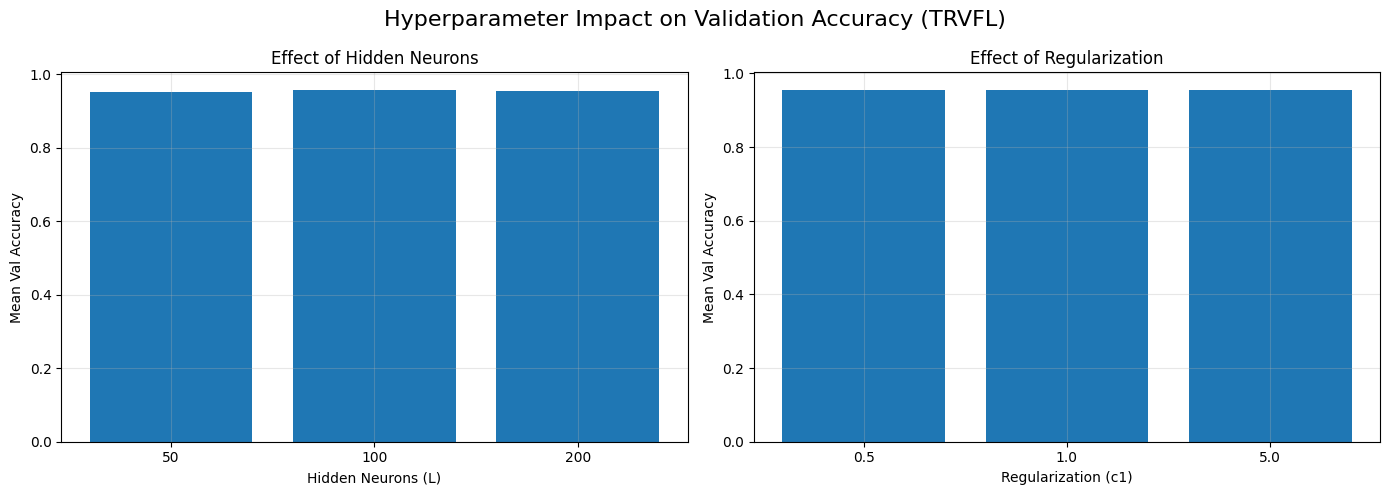

In [ ]:
# ====================================================
# VISUALIZE HYPERPARAMETER IMPACT
# ====================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hyperparameter Impact on Validation Accuracy (TRVFL)', fontsize=16)

# Hidden Neurons (L)
ax = axes[0]
L_data = results_df.groupby('L')['val_acc'].mean().sort_index()
ax.bar(range(len(L_data)), L_data.values)
ax.set_xticks(range(len(L_data)))
ax.set_xticklabels(L_data.index)
ax.set_ylabel('Mean Val Accuracy')
ax.set_xlabel('Hidden Neurons (L)')
ax.set_title('Effect of Hidden Neurons')
ax.grid(True, alpha=0.3)

# Regularization (c1)
ax = axes[1]
c1_data = results_df.groupby('c1')['val_acc'].mean().sort_index()
ax.bar(range(len(c1_data)), c1_data.values)
ax.set_xticks(range(len(c1_data)))
ax.set_xticklabels(c1_data.index)
ax.set_ylabel('Mean Val Accuracy')
ax.set_xlabel('Regularization (c1)')
ax.set_title('Effect of Regularization')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

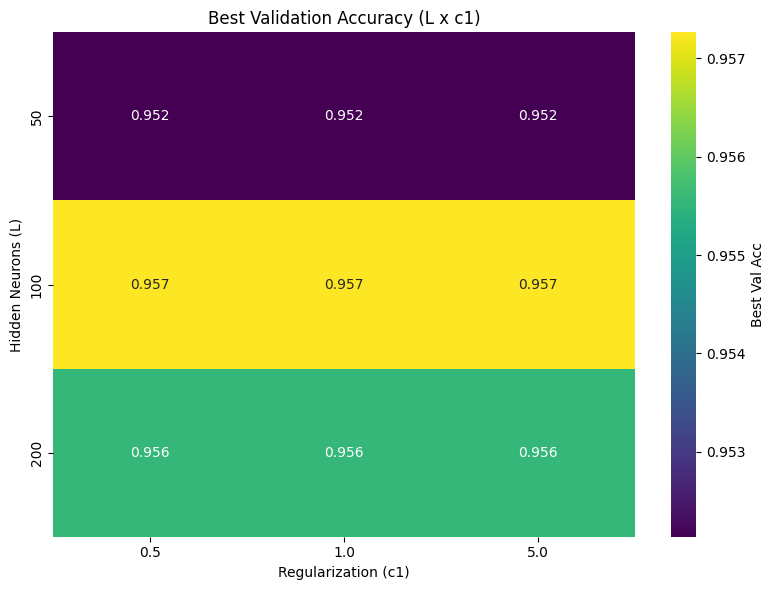

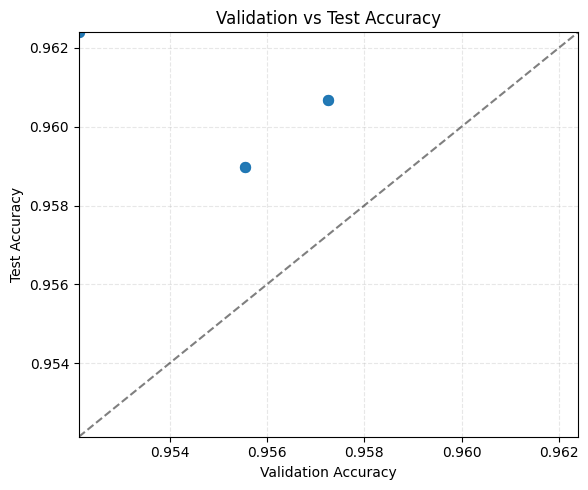

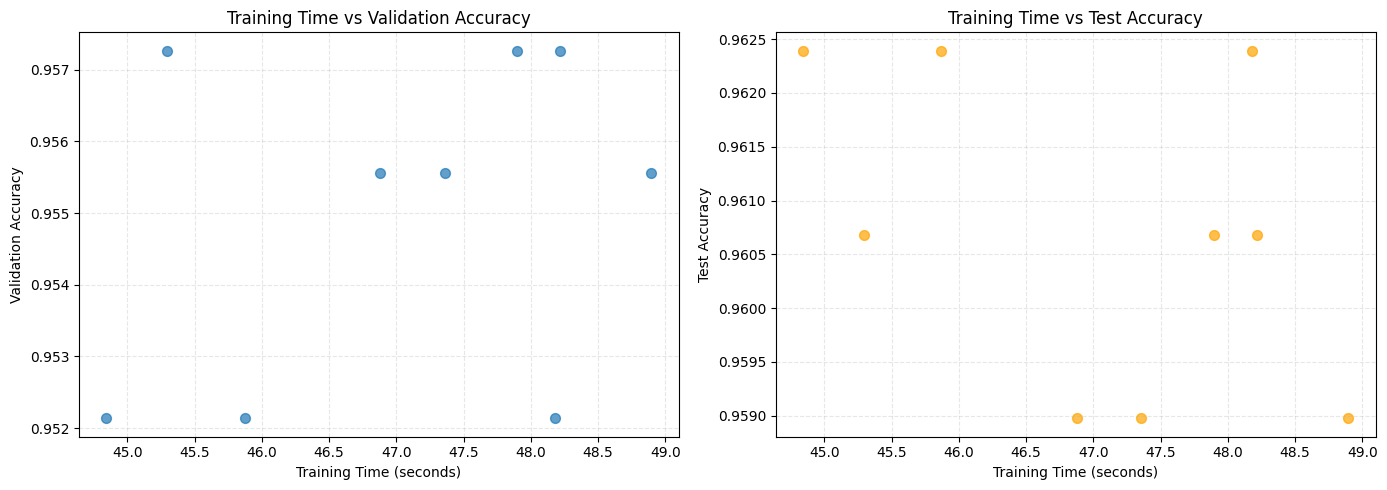

In [ ]:
# ====================================================
# ADDITIONAL HYPERPARAMETER GRAPHS
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Heatmap: L x c1 -> best val_acc
try:
    pivot_L_c1 = (
        results_df.groupby(['L', 'c1'])['val_acc']
        .max()
        .unstack('c1')
        .sort_index()
    )
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_L_c1, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'Best Val Acc'})
    plt.title('Best Validation Accuracy (L x c1)')
    plt.xlabel('Regularization (c1)')
    plt.ylabel('Hidden Neurons (L)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Heatmap not shown: {e}")

# 2) Scatter: Val vs Test accuracy correlation
try:
    plt.figure(figsize=(6, 5))
    plt.scatter(results_df['val_acc'], results_df['test_acc'], s=50, alpha=0.7)
    lims = [results_df[['val_acc', 'test_acc']].min().min(), results_df[['val_acc', 'test_acc']].max().max()]
    plt.plot(lims, lims, 'k--', alpha=0.5)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.xlabel('Validation Accuracy')
    plt.ylabel('Test Accuracy')
    plt.title('Validation vs Test Accuracy')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Val vs Test scatter not shown: {e}")

# 3) Training time vs accuracy
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(results_df['training_time'], results_df['val_acc'], s=50, alpha=0.7)
    ax.set_xlabel('Training Time (seconds)')
    ax.set_ylabel('Validation Accuracy')
    ax.set_title('Training Time vs Validation Accuracy')
    ax.grid(True, linestyle='--', alpha=0.3)

    ax = axes[1]
    ax.scatter(results_df['training_time'], results_df['test_acc'], s=50, alpha=0.7, color='orange')
    ax.set_xlabel('Training Time (seconds)')
    ax.set_ylabel('Test Accuracy')
    ax.set_title('Training Time vs Test Accuracy')
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Training time plots not shown: {e}")

FINAL EVALUATION WITH BEST MODEL

Best Hyperparameters:
  L: 100
  c1: 0.5
  random_state: 42

Best Model Performance:
  Training Accuracy: 1.0000 (100.00%)
  Validation Accuracy: 0.9573 (95.73%)
  Test Accuracy: 0.9607 (96.07%)
  Training Time: 45.3s

Best Model - Test Set Confusion Matrix:


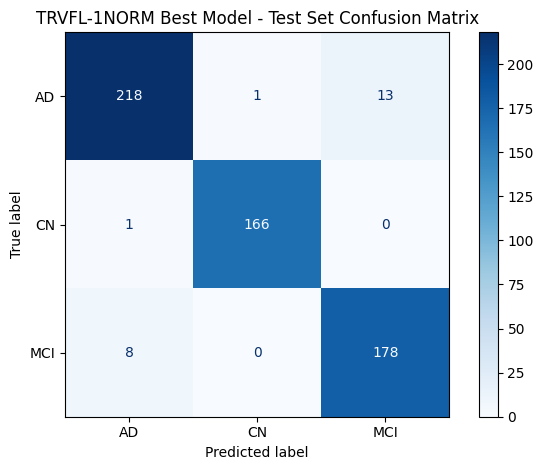


Mean predicted probability per class (Test Set):
  AD: 0.3805
  CN: 0.3037
  MCI: 0.3157

✅ Best model parameters saved to 'best_trvfl_model.npz'


In [ ]:
# ====================================================
# EVALUATE BEST MODEL ON TEST SET (Multi-class)
# ====================================================
print("="*60)
print("FINAL EVALUATION WITH BEST MODEL")
print("="*60)
print(f"\nBest Hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

print(f"\nBest Model Performance:")
print(f"  Training Accuracy: {best_result['train_acc']:.4f} ({best_result['train_acc']*100:.2f}%)")
print(f"  Validation Accuracy: {best_result['val_acc']:.4f} ({best_result['val_acc']*100:.2f}%)")
print(f"  Test Accuracy: {best_result['test_acc']:.4f} ({best_result['test_acc']*100:.2f}%)")
print(f"  Training Time: {best_result['training_time']:.1f}s")

# Display confusion matrix for best model
print("\nBest Model - Test Set Confusion Matrix:")
disp = ConfusionMatrixDisplay(
    confusion_matrix=best_result['results']['test_confmat'],
    display_labels=class_names
)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('TRVFL-1NORM Best Model - Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

# Probability calibration summary
probs = best_result['results']['test_probs']
print("\nMean predicted probability per class (Test Set):")
for i, name in enumerate(class_names):
    print(f"  {name}: {probs[:, i].mean():.4f}")

# Save best model parameters
np.savez('best_trvfl_model.npz',
         w_vec=best_result['results']['w_vec'],
         b_vec=best_result['results']['b_vec'],
         L=best_params['L'],
         c1=best_params['c1'])
print("\n✅ Best model parameters saved to 'best_trvfl_model.npz'")

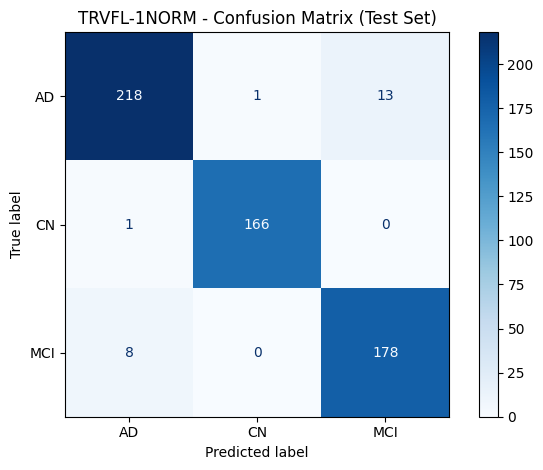


Classification Report (Test Set):
              precision    recall  f1-score   support

          AD     0.9604    0.9397    0.9499       232
          CN     0.9940    0.9940    0.9940       167
         MCI     0.9319    0.9570    0.9443       186

    accuracy                         0.9607       585
   macro avg     0.9621    0.9636    0.9627       585
weighted avg     0.9609    0.9607    0.9607       585



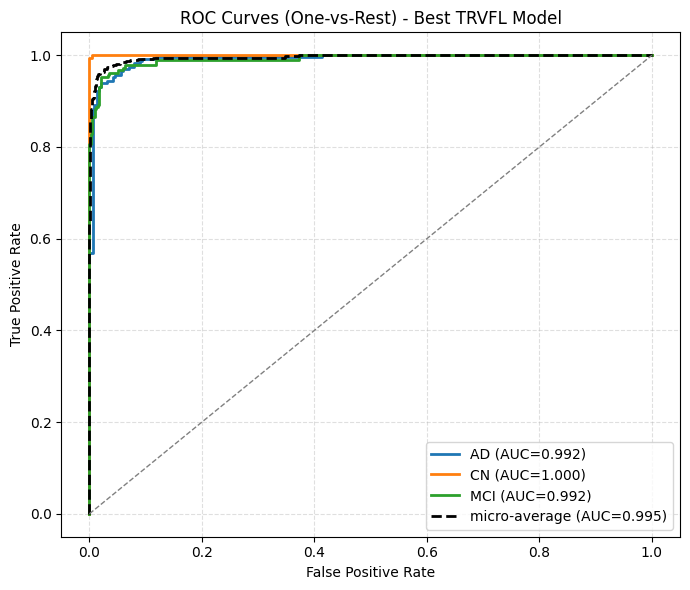

Weighted ROC–AUC (OVR): 0.9942


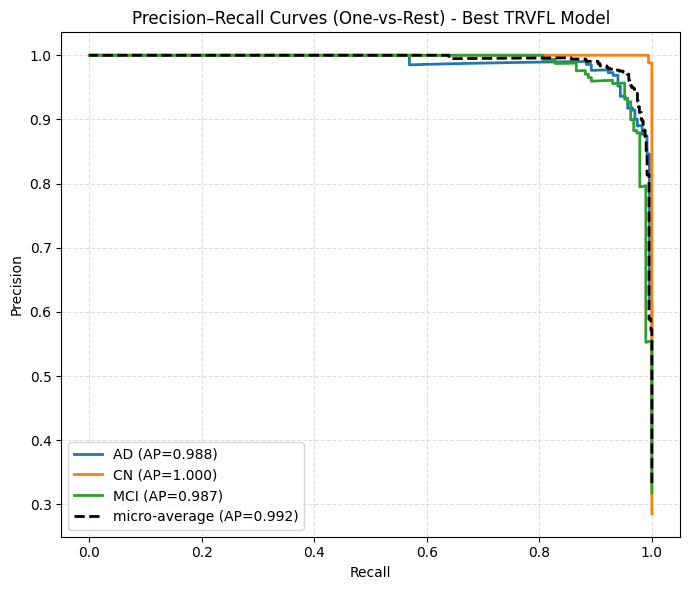

Weighted Average Precision (OVR): 0.9910

Predicted Class Distribution (Test Set):
  AD: 227 (38.80%)
  CN: 167 (28.55%)
  MCI: 191 (32.65%)

Per-Class Accuracy:
  AD: 0.9397 (93.97%)
  CN: 0.9940 (99.40%)
  MCI: 0.9570 (95.70%)


In [ ]:
# ====================================================
# CONFUSION MATRIX + ROC/PR FOR BEST MODEL (Multi-class)
# ====================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# Use probabilities from best_result if available
best_test_probs = best_result['results']['test_probs']
all_preds = best_result['results']['pred_test']
all_labels = y_test

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('TRVFL-1NORM - Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

print("\nClassification Report (Test Set):")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# -----------------------------
# ROC Curves and AUC (multi-class OVR using probabilities)
# -----------------------------
try:
    num_classes = len(class_names)
    y_true_bin = label_binarize(all_labels, classes=range(num_classes))

    plt.figure(figsize=(7, 6))
    aucs = []
    for i in range(num_classes):
        fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], best_test_probs[:, i])
        auc_i = auc(fpr_i, tpr_i)
        aucs.append(auc_i)
        plt.plot(fpr_i, tpr_i, lw=2, label=f"{class_names[i]} (AUC={auc_i:.3f})")

    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), best_test_probs.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, color='black', lw=2, linestyle='--', label=f"micro-average (AUC={auc_micro:.3f})")

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (One-vs-Rest) - Best TRVFL Model')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    roc_auc_weighted = roc_auc_score(y_true_bin, best_test_probs, average='weighted', multi_class='ovr')
    print(f"Weighted ROC–AUC (OVR): {roc_auc_weighted:.4f}")
except Exception as e:
    print(f"ROC–AUC not available: {e}")

# -----------------------------
# Precision–Recall Curves
# -----------------------------
try:
    num_classes = len(class_names)
    y_true_bin = label_binarize(all_labels, classes=range(num_classes))

    plt.figure(figsize=(7, 6))
    aps = []
    for i in range(num_classes):
        precision_i, recall_i, _ = precision_recall_curve(y_true_bin[:, i], best_test_probs[:, i])
        ap_i = average_precision_score(y_true_bin[:, i], best_test_probs[:, i])
        aps.append(ap_i)
        plt.plot(recall_i, precision_i, lw=2, label=f"{class_names[i]} (AP={ap_i:.3f})")

    precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), best_test_probs.ravel())
    ap_micro = average_precision_score(y_true_bin, best_test_probs, average='micro')
    plt.plot(recall_micro, precision_micro, color='black', lw=2, linestyle='--', label=f"micro-average (AP={ap_micro:.3f})")

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall Curves (One-vs-Rest) - Best TRVFL Model')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print(f"Weighted Average Precision (OVR): {average_precision_score(y_true_bin, best_test_probs, average='weighted'):.4f}")
except Exception as e:
    print(f"PR curves not available: {e}")

# Distribution summary
print("\nPredicted Class Distribution (Test Set):")
for cls_idx, cls_name in enumerate(class_names):
    count = np.sum(all_preds == cls_idx)
    print(f"  {cls_name}: {count} ({count/len(all_preds)*100:.2f}%)")

print("\nPer-Class Accuracy:")
for cls_idx, cls_name in enumerate(class_names):
    mask = (all_labels == cls_idx)
    if mask.sum() > 0:
        acc = np.mean(all_preds[mask] == all_labels[mask])
        print(f"  {cls_name}: {acc:.4f} ({acc*100:.2f}%)")

## TRVFL-1NORM Hyperparameter Tuning Summary

This notebook implements **TRVFL-1NORM (Twin Random Vector Functional Link with 1-Norm)** for multi-class Alzheimer's disease classification.

### Model Overview:
TRVFL-1NORM is a neural network-based classifier that:
- Uses random feature expansion with sigmoid activation
- Employs one-vs-rest strategy for multi-class problems
- Solves quadratic programming (QP) problems for optimal hyperplanes
- Provides fast training through closed-form solutions

### Tunable Parameters:
- **L (Hidden Neurons)**: Number of random neurons in hidden layer (50, 100, 200, 300)
- **c1 (Regularization)**: Controls model complexity and generalization (0.1, 0.5, 1.0, 5.0, 10.0)

### Features:
1. **Grid Search**: Systematic exploration of hyperparameter combinations
2. **Configurable Grid**: Switch between small (fast) and full (comprehensive) search
3. **Automatic Best Model Selection**: Based on validation accuracy
4. **Results Export**: CSV file with all combinations and metrics
5. **Visualizations**: Impact analysis for each hyperparameter
6. **Model Persistence**: Best model parameters saved automatically

### Key Advantages:
- Fast training (no iterative optimization)
- No deep learning frameworks required
- Effective for tabular/feature-based data
- Built-in regularization through QP formulation

### Usage Tips:
- Set `use_small_grid = True` for faster experimentation
- Set `use_small_grid = False` for exhaustive search
- Adjust `param_grid` or `param_grid_small` to customize search space
- Monitor validation accuracy to detect overfitting
- Larger L increases capacity but may overfit
- Smaller c1 increases regularization